<a href="https://colab.research.google.com/github/crowell97/ES2245/blob/main/es2245_lecture25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Lecture 25: Spatial Datasets

**Course:** EARTHSC 2245 - Introductory Data Analysis for Earth and Environmental Sciences

This notebook explores various ways to download geospatial data and manipulate it


##Global Temperatures
1: We are going to use MERRA-2 (Modern-Era Retrospective analysis for Research and Applications). Instead of a camera on a satellite taking individual snapshots, MERRA-2 is a continuous, mathematically modeled grid of the entire planet that incorporates satellite data.

In [22]:
# Install the necessary libraries
!pip install earthaccess xarray netCDF4 h5netcdf cartopy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.5 MB/s eta 0:00:00


In [28]:
import earthaccess
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Set plotting style
plt.style.use('ggplot')
%matplotlib inline

##Authentication

You will need a NASA Earthdata login to perform this notebook. In addition, you will need to authorize specific applications. For this one, its NASA GESDISC DATA ARCHIVE that you will need to add.

In [29]:
# Authenticate with NASA Earthdata
auth = earthaccess.login(strategy="interactive")

if auth.authenticated:
    print("Successfully authenticated with NASA Earthdata.")
else:
    print("Authentication failed.")

Successfully authenticated with NASA Earthdata.


##Search for Global Data

We are searching for the M2T1NXSLV product. This contains 2-dimensional, hourly, single-level atmospheric diagnostics (including 2-meter air temperature).

In [30]:
# Search for just one day of data.
# In MERRA-2, 1 granule contains 24 hourly global snapshots for that specific day.
results = earthaccess.search_data(
    short_name='M2T1NXSLV',
    temporal=("2025-01-01", "2025-01-01"),
    count=1
)

print(f"Found {len(results)} global granule.")

Found 1 global granule.


/usr/local/lib/python3.12/dist-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


##Cloud-Native Loading
We use earthaccess.open() to stream the file, and pass it directly to xarray.

In [32]:
# 1. Download the file locally (This handles all the complex authentication perfectly)
print("Downloading MERRA-2 data...")
downloaded_files = earthaccess.download(results, local_path=".")

# 2. Open the newly downloaded local file
# earthaccess.download returns a list of file paths (e.g., ['./MERRA2_400.tavg...nc4'])
ds = xr.open_dataset(downloaded_files[0], engine='h5netcdf')

print("\nDataset loaded successfully! Available variables include:")
print(list(ds.data_vars.keys())[:10])

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]


Dataset loaded successfully! Available variables include:
['CLDPRS', 'CLDTMP', 'DISPH', 'H1000', 'H250', 'H500', 'H850', 'OMEGA500', 'PBLTOP', 'PS']


##Data Extraction and Math
The dataset contains a variable called T2M (2-meter air temperature). It has three dimensions: Time (24 hours), Latitude, and Longitude. We will isolate a single hour and convert the units.

In [33]:
# Extract the temperature variable
temp_kelvin = ds['T2M']

# Isolate the 12th hour of the day (Noon UTC) using .isel() (index selection)
temp_kelvin_noon = temp_kelvin.isel(time=12)

# Convert from Kelvin to Celsius
temp_celsius = temp_kelvin_noon - 273.15

print(f"Global Temp Range: {float(temp_celsius.min()):.1f}°C to {float(temp_celsius.max()):.1f}°C")

Global Temp Range: -55.0°C to 42.2°C


##Publication-Quality Mapping
Because this data covers the whole globe, standard plots look distorted at the poles. We will use Cartopy to wrap our data onto a Robinson projection (a classic map shape).

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


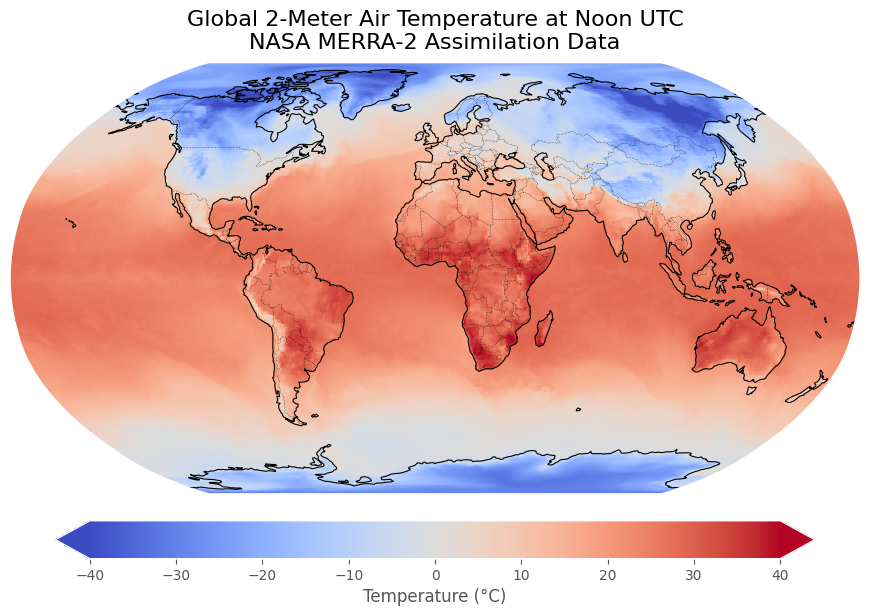

In [34]:
# 1. Setup a Cartopy Figure with a Robinson Projection
fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

# 2. Add geographic features for context
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
ax.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle=':', edgecolor='black')

# 3. Plot the data
# CRITICAL: We must use transform=ccrs.PlateCarree() to tell Cartopy
# that our raw data is in standard Latitude/Longitude coordinates.
plot = temp_celsius.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',       # Blue for cold, Red for hot
    vmin=-40, vmax=40,     # Lock the color scale from -40C to 40C
    cbar_kwargs={
        'label': 'Temperature (°C)',
        'shrink': 0.7,
        'orientation': 'horizontal',
        'pad': 0.05
    }
)

# 4. Final touches
ax.set_title("Global 2-Meter Air Temperature at Noon UTC\nNASA MERRA-2 Assimilation Data", fontsize=16, pad=10)
plt.show()

##2: Mapping Ocean Currents with High-Resolution Sea Surface Temp

For this section, we are going to use a Level 4 (L4) dataset. In NASA terminology, Level 4 means the data has been mathematically gridded and gap-filled.


We will map the Gulf Stream using the MUR SST (Multi-scale Ultra-high Resolution Sea Surface Temperature) dataset. It provides a stunning, high-definition look at ocean currents, and it works perfectly right out of the box.

We will use standard scientific libraries. cartopy handles the map projections, and xarray handles the multi-dimensional NetCDF data.

In [35]:
!pip install earthaccess xarray netCDF4 cartopy matplotlib

In [36]:
import earthaccess
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Set a dark background style to make the ocean temperatures pop
plt.style.use('dark_background')
%matplotlib inline

##Authentication
Because we are pulling from PO.DAAC, this standard login is all you need.

In [37]:
auth = earthaccess.login(strategy="interactive")

if auth.authenticated:
    print("Successfully authenticated with NASA Earthdata.")
else:
    print("Authentication failed. Please check credentials.")

Successfully authenticated with NASA Earthdata.


##Data Discovery
We are searching for MUR-JPL-L4-GLOB-v4.1. This is a daily, global dataset with an incredible 1km resolution. We will grab just a single day's file.

In [38]:
# Search for MUR SST for a specific day in the summer
results = earthaccess.search_data(
    short_name='MUR-JPL-L4-GLOB-v4.1',
    temporal=("2025-08-01", "2025-08-01"),
    count=1
)

print(f"Found {len(results)} global dataset.")

Found 1 global dataset.


/usr/local/lib/python3.12/dist-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


##Download and Load
Because this is a 1km global dataset, the file is about 400MB. We will download it locally to ensure a perfectly stable connection, then open it with xarray.

In [39]:
print("Downloading high-resolution SST data (approx 400MB)...")
downloaded_files = earthaccess.download(results, local_path=".")

# Open the downloaded file
ds = xr.open_dataset(downloaded_files[0])

print("\nDataset successfully loaded! Variables:")
print(list(ds.data_vars.keys()))

/usr/local/lib/python3.12/dist-packages/earthaccess/store.py:832: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum(granule.size() for granule in granules) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]


Dataset successfully loaded! Variables:
['analysed_sst', 'analysis_error', 'mask', 'sea_ice_fraction', 'dt_1km_data', 'sst_anomaly']


##Spatial Subsetting (The Gulf Stream)
Opening a 400MB global file takes memory, so we will immediately slice out the exact region we care about: the Eastern US Coast / Atlantic Ocean, where the warm Gulf Stream flows.

In [40]:
print("Downloading high-resolution SST data (approx 400MB)...")
downloaded_files = earthaccess.download(results, local_path=".")

# Open the downloaded file
ds = xr.open_dataset(downloaded_files[0])

print("\nDataset successfully loaded! Variables:")
print(list(ds.data_vars.keys()))

/usr/local/lib/python3.12/dist-packages/earthaccess/store.py:832: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum(granule.size() for granule in granules) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]


Dataset successfully loaded! Variables:
['analysed_sst', 'analysis_error', 'mask', 'sea_ice_fraction', 'dt_1km_data', 'sst_anomaly']


##High-Definition Cartography
Now we plot the data. Because MUR is so high-resolution, we can see the literal eddies and swirls of the ocean currents. We will use the turbo colormap, which is excellent for highlighting fine temperature gradients.

In [41]:
# The dataset uses 'lat' and 'lon'. We use xarray's .sel() to slice a bounding box.
# Note: lat goes from south to north, lon from west to east
gulf_stream = ds.sel(
    lat=slice(25.0, 45.0),  # Florida to Nova Scotia
    lon=slice(-85.0, -50.0) # Gulf of Mexico to Mid-Atlantic
)

# Extract the analysed sea surface temperature variable
sst_kelvin = gulf_stream['analysed_sst']

# Convert from Kelvin to Celsius
sst_celsius = sst_kelvin - 273.15

# Drop the time dimension since we only have 1 day
sst_celsius = sst_celsius.squeeze()

print("Data subset and converted to Celsius.")
print(f"Temperature Range: {float(sst_celsius.min()):.1f}°C to {float(sst_celsius.max()):.1f}°C")

Data subset and converted to Celsius.
Temperature Range: 13.3°C to 31.9°C


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


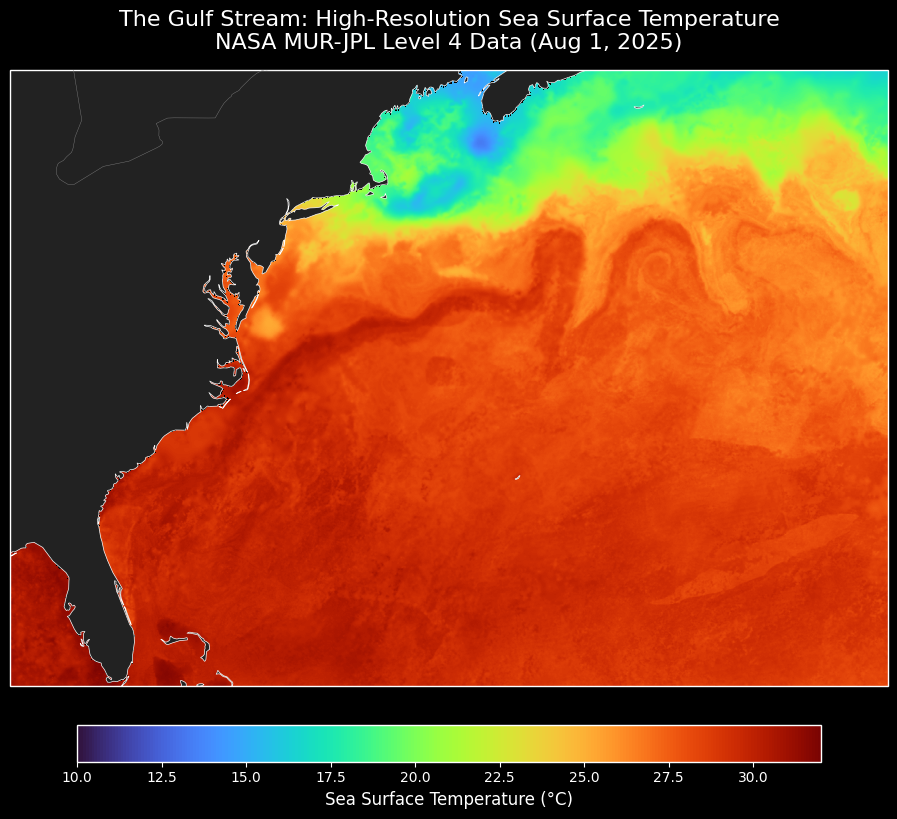

In [42]:
# 1. Set up the map projection
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())

# 2. Add landmasses to mask out the empty values over the continents
# We use a solid color for land to make the ocean data stand out
ax.add_feature(cfeature.LAND, facecolor='#222222', zorder=2)
ax.add_feature(cfeature.COASTLINE, edgecolor='white', linewidth=0.5, zorder=3)
ax.add_feature(cfeature.BORDERS, edgecolor='gray', linewidth=0.3, zorder=3)

# 3. Plot the Sea Surface Temperature
# We use PlateCarree transform because the raw data is in simple Lat/Lon
plot = sst_celsius.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='turbo',        # High-contrast scientific colormap
    vmin=10, vmax=32,    # Cap the color scale between 10C and 32C
    add_colorbar=False,  # We will build a custom colorbar below
    zorder=1
)

# 4. Add a clean, horizontal colorbar
cbar = plt.colorbar(plot, orientation='horizontal', pad=0.05, shrink=0.8)
cbar.set_label('Sea Surface Temperature (°C)', color='white', size=12)
cbar.ax.xaxis.set_tick_params(color='white', labelcolor='white')

# 5. Final Formatting
ax.set_title(
    "The Gulf Stream: High-Resolution Sea Surface Temperature\nNASA MUR-JPL Level 4 Data (Aug 1, 2025)",
    color='white',
    fontsize=16,
    pad=15
)

# Set the geographic extent to match our sliced data
ax.set_extent([-85, -50, 25, 45], crs=ccrs.PlateCarree())

plt.show()

###3: Tracking the 2025 Kamchatka Tsunami with SWOT Satellite Altimetry

Because SWOT uses a wide-swath radar altimeter (the KaRIn instrument), it provides unprecedented 2D maps of Sea Surface Height Anomalies (SSHA), making it uniquely capable of capturing the fine-scale wave dispersion of a tsunami as it propagates across the Pacific.



In [43]:
# Install the necessary geospatial and data retrieval libraries
!pip install earthaccess xarray h5netcdf cartopy matplotlib numpy

In [44]:
import earthaccess
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Set a dark background style to make the wave anomalies pop
plt.style.use('dark_background')
%matplotlib inline

In [53]:
# Authenticate with NASA Earthdata
auth = earthaccess.login(strategy="interactive")

if auth.authenticated:
    print("Successfully authenticated with NASA Earthdata.")
else:
    print("Authentication failed. Please check your credentials.")

Successfully authenticated with NASA Earthdata.


##Querying the SWOT Database
The M8.8 Kamchatka earthquake struck on July 29, 2025. We will search for the SWOT Level 2 Low-Rate Sea Surface Height (LR SSH) product, which is specifically designed to measure ocean topography at a resolution capable of resolving tsunami dispersion.

In [63]:
import earthaccess

# 1. Search for the active SWOT datasets to confirm the Version D short_name
datasets = earthaccess.search_datasets(
    keyword="SWOT L2 KaRIn Low Rate Sea Surface Height"
)

print("Active SWOT Datasets:")
for ds in datasets[:5]: # Print the top few to find the exact name
    short_name = ds.get('umm', {}).get('ShortName')
    version = ds.get('umm', {}).get('Version')
    print(f"Short Name: {short_name} | Version: {version}")

# 2. Update the search using the newer Version D short_name (e.g., swapping _2.0 for _3.0)
# Replace "SWOT_L2_LR_SSH_3.0" below with the exact short_name found in the printout above.
results = earthaccess.search_data(
    short_name="SWOT_L2_LR_SSH_D",
    temporal=("2025-07-29", "2025-07-31")
)

print(f"\nFound {len(results)} SWOT granules globally.")

for r in results[:10]:
    print(r.data_links()[0].split('/')[-1])

Active SWOT Datasets:
Short Name: SWOT_L2_LR_SSH_2.0 | Version: 2.0
Short Name: SWOT_L2_LR_SSH_D | Version: D
Short Name: SWOT_L2_LR_PreCalSSH_D | Version: D
Short Name: SWOT_L2_LR_SSH_BASIC_2.0 | Version: 2.0
Short Name: SWOT_L2_LR_SSH_BASIC_D | Version: D

Found 340 SWOT granules globally.
SWOT_L2_LR_SSH_Basic_036_239_20250728T235558_20250729T004727_PID0_01.nc
SWOT_L2_LR_SSH_Expert_036_239_20250728T235558_20250729T004727_PID0_01.nc
SWOT_L2_LR_SSH_Unsmoothed_036_239_20250728T235559_20250729T004726_PID0_01.nc
SWOT_L2_LR_SSH_WindWave_036_239_20250728T235558_20250729T004727_PID0_01.nc
SWOT_L2_LR_SSH_Expert_036_240_20250729T004725_20250729T013853_PID0_01.nc
SWOT_L2_LR_SSH_Basic_036_240_20250729T004725_20250729T013853_PID0_01.nc
SWOT_L2_LR_SSH_WindWave_036_240_20250729T004725_20250729T013853_PID0_01.nc
SWOT_L2_LR_SSH_Unsmoothed_036_240_20250729T004726_20250729T013853_PID0_01.nc
SWOT_L2_LR_SSH_Basic_036_241_20250729T013852_20250729T023020_PID0_01.nc
SWOT_L2_LR_SSH_WindWave_036_241_20250729T

/usr/local/lib/python3.12/dist-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


##Download and Load

SWOT files are stored as NetCDF4/HDF5 files. Because satellite swaths follow a curved orbital path, their internal grids are not simple squares; we will load the file natively using xarray.

In [64]:
print("Downloading SWOT swath data...")
# Download the first swath that captured the region to the local directory
downloaded_files = earthaccess.download(results[0:1], local_path=".")

# Load the file into xarray using the h5netcdf engine
ds = xr.open_dataset(downloaded_files[0], engine='h5netcdf')

print("\nDataset successfully loaded! Key variables related to Sea Surface Height:")
# Filter the variable list to show only the SSHA (Sea Surface Height Anomaly) variables
print([var for var in ds.data_vars.keys() if 'ssha' in var])

/usr/local/lib/python3.12/dist-packages/earthaccess/store.py:832: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum(granule.size() for granule in granules) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]


Dataset successfully loaded! Key variables related to Sea Surface Height:
['ssha_karin', 'ssha_karin_qual', 'ssha_karin_2', 'ssha_karin_2_qual']


##Visualizing the Tsunami's Oceanic Signature

To map satellite swath data without distorting the pixels, it is often best to plot the raw coordinates directly using a scatter plot rather than forcing it into a rectangular grid. We will use the seismic colormap to distinctly show wave crests (red) and wave troughs (blue).

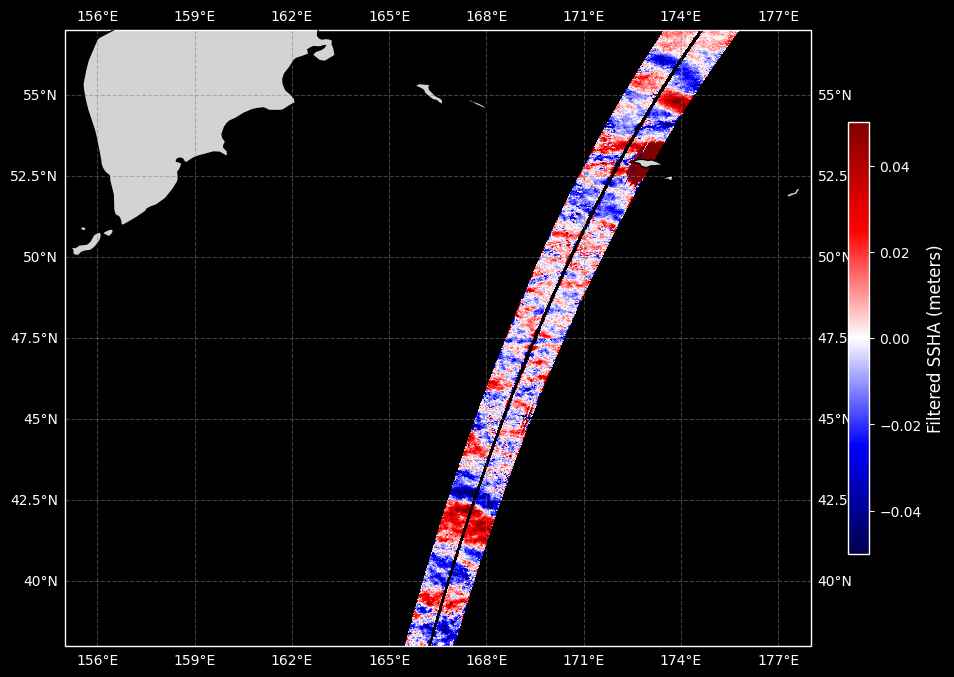

In [80]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from scipy.ndimage import gaussian_filter

# 1. Extract the arrays
lon = ds['longitude'].values
lat = ds['latitude'].values
ssha = ds['ssha_karin_2'].values

fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=1, zorder=3)
ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5)

# 2. 1D Along-Track Filter (Prevents the Nadir Gap from ruining the data)
# We fill NaNs temporarily, but we ONLY blur along the flight path (axis=0)
ssha_filled = np.nan_to_num(ssha, nan=np.nanmean(ssha))

# Applying the filter strictly along the track prevents cross-track bleeding
background_ocean = gaussian_filter(ssha_filled, sigma=(15, 0))
tsunami_ripples = ssha - background_ocean

# 3. Center the data and mask the NaNs back out
valid_mask = ~np.isnan(ssha)
tsunami_ripples[~valid_mask] = np.nan

# Subtract the median of the valid data to perfectly center it around 0
valid_ripples = tsunami_ripples[valid_mask]
tsunami_ripples = tsunami_ripples - np.median(valid_ripples)

# 4. Hybrid Color Scaling: Dynamic but Hard-Capped
vmin_dyn = np.percentile(valid_ripples, 2)
vmax_dyn = np.percentile(valid_ripples, 98)
v_limit = max(abs(vmin_dyn), abs(vmax_dyn))

# Force the limit to NEVER exceed 0.05 meters so the waves can't be washed out
v_limit = min(v_limit, 0.05)

# Plot the data!
pm = ax.pcolormesh(
    lon, lat, tsunami_ripples,
    cmap='seismic',
    vmin=-v_limit,
    vmax=v_limit,
    transform=ccrs.PlateCarree(),
    zorder=1
)

# 5. Auto-Zoom directly to the valid data
valid_lons = lon[valid_mask]
valid_lats = lat[valid_mask]

if len(valid_lons) > 0:
    ax.set_extent([
        valid_lons.min() - 2, valid_lons.max() + 2,
        valid_lats.min() - 2, valid_lats.max() + 2
    ], crs=ccrs.PlateCarree())

cbar = plt.colorbar(pm, ax=ax, orientation='vertical', pad=0.04, shrink=0.7)
cbar.set_label('Filtered SSHA (meters)', fontsize=12)
ax.set_extent([155.0, 178.0, 38.0, 57.0], crs=ccrs.PlateCarree())

plt.show()